# Pseudocount analysis

Layout the problem with deconvolving low occupancy bins in the chromatin clearly. And brainstorm possibly, elegant solutions.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Load the MNase data for a cycling window:

from src.chromatin_model import read_chromosome_mnase_reads
from src.global_config import GlobalConstants

chr_reads = read_chromosome_mnase_reads(chr=16, replicate=1)
mnase_span = (771600, 771900)

locus_reads = chr_reads[(chr_reads.mid > mnase_span[0]) & 
                        (chr_reads.mid < mnase_span[1])]


In [3]:
from src.chromatin_model import create_exact_bins, downsample_bins, normalize_bins_by_len

timepoints = GlobalConstants.CHROM_WT1_TIMEPOINTS
exact_bins = create_exact_bins(locus_reads, mnase_span, timepoints)
normalized_bins = normalize_bins_by_len(1, exact_bins, log=False)


In [5]:
downsampled_bins = downsample_bins(normalized_bins, mnase_span, GlobalConstants.BIN_WIDTH, 
    GlobalConstants.BIN_HEIGHT, GlobalConstants.MAX_Y_LEN, timepoints)

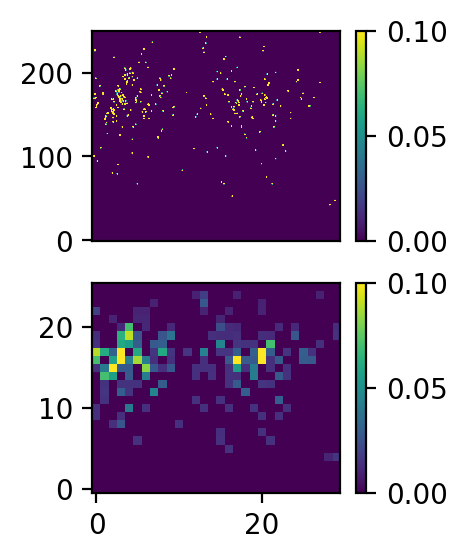

In [6]:
fig = plt.figure(figsize=(2, 3))
plt.subplot(2, 1, 1)
plt.imshow(exact_bins[0], vmax=0.1, vmin=0, aspect='auto', origin='lower')
plt.colorbar()
plt.xticks([])

plt.subplot(2, 1, 2)
plt.imshow(downsampled_bins[0], vmax=0.1, vmin=0, aspect='auto', origin='lower')
plt.colorbar()

In [7]:
from src.deconvolution_solver import DeconvolutionSolver
from src.config import load_default_chrom_configs
from src.chromatin_deconvolution_solver import ChromatinDeconvolveSolver

config, _ = load_default_chrom_configs()
#config.shift_parameters_for_alpha()

config.params_dic.update({
    'mu0': 9.361663,
    'lambda': 60.397553,
    'delta': 14.577271,
    'sigma0': 5.884135,
    'sigmav': 0.044401,
    'gamma1': 0.586077,
    'gamma2': 1.000000,
    'halted': 0.000050,  
})

config.update_timepoints()
H = config.calculate_H()

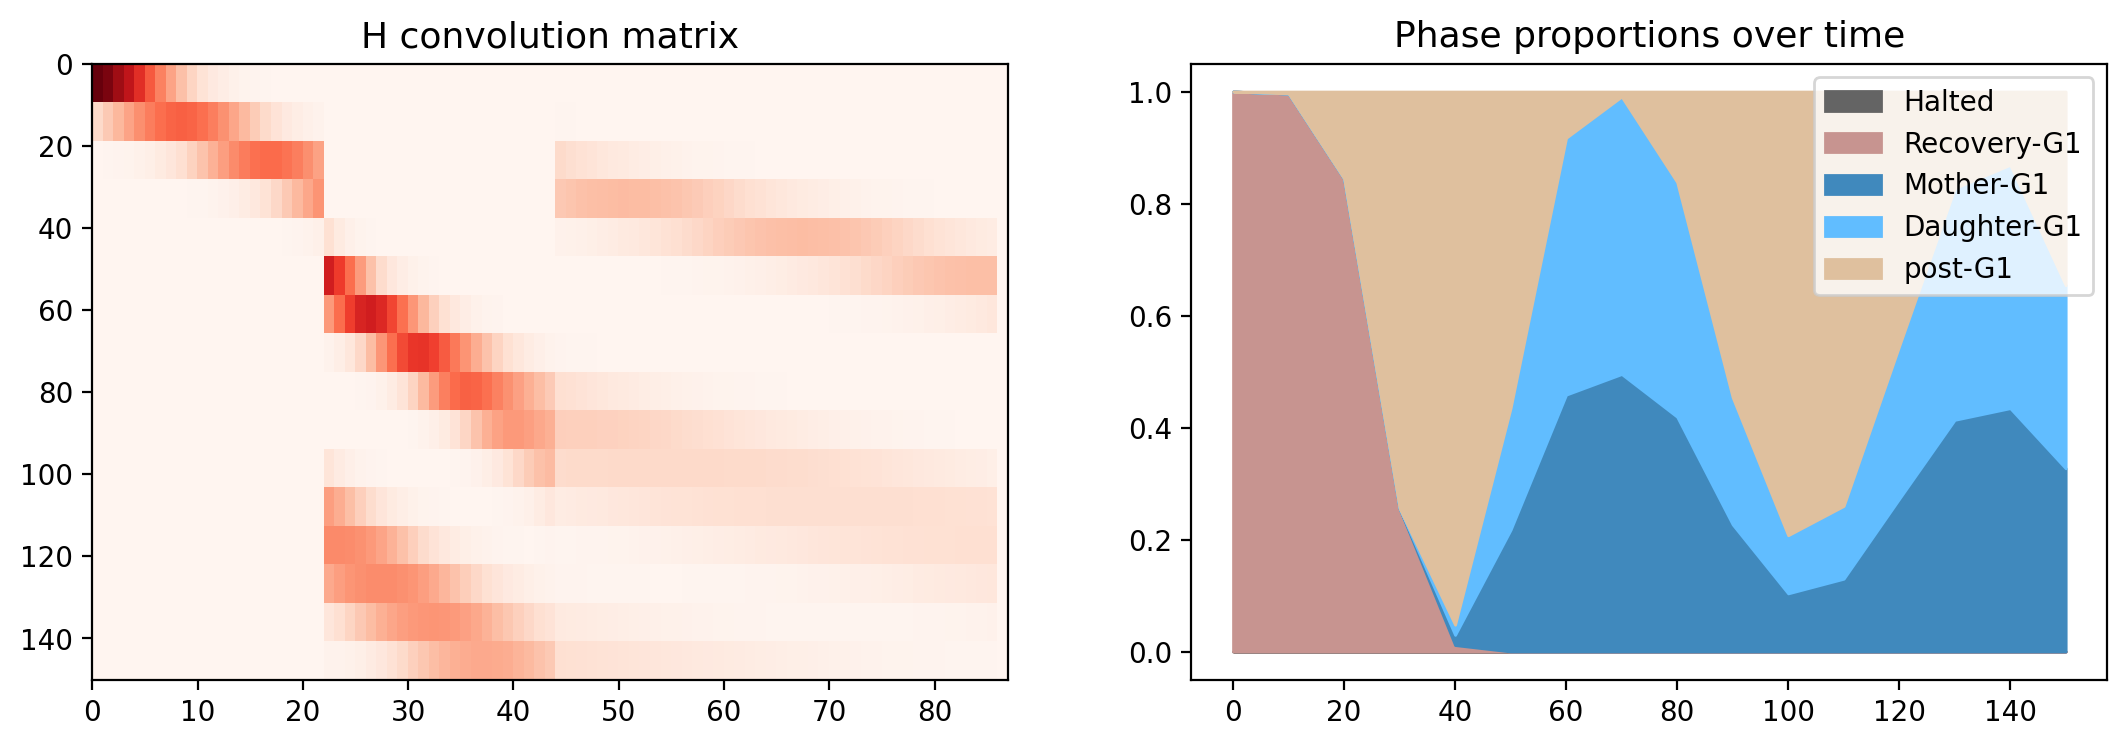

In [8]:
config.plot_H()

In [11]:
padding_type = 'none'

b = 1

chr4_n = np.array([1.00442364, 1.00347336, 0.97773201, 0.8061213 , 0.66388052,
       0.84322967, 0.99955218, 1.00893152, 0.97884289, 0.85742082,
       0.75599297, 0.76982516, 0.84182678, 0.97059662, 0.99078551,
       0.91119956])

chr4_N_test = np.diag(chr4_n)

sample_f_replication = np.array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 1.])

G = downsampled_bins.reshape((downsampled_bins.shape[0], -1))
selected_examples_G = G[:, [493]]

In [123]:
chromatin_solver = ChromatinDeconvolveSolver(config, config.H, 
    selected_examples_G, chr4_N_test, b, sample_f_replication, padding_type=padding_type)

In [124]:
gamma = 0.004

gamma_sweep = np.linspace(0.001, 0.01, 20)
sns = []
rns = []
Fs = np.zeros((len(gamma_sweep), H.shape[1]))

for i, gamma in enumerate(gamma_sweep):
    F = chromatin_solver.deconvolve_G_iteratively(gamma=gamma, verbose=False)
    rns.append(chromatin_solver.rn)
    sns.append(chromatin_solver.sn)
    Fs[i] = F.flatten()

gamma_sweep_results_df = pd.DataFrame({'rn': rns, 'sn': sns}, index=gamma_sweep)

0/1 - 00:00:00.048
0/1 - 00:00:00.045
0/1 - 00:00:00.049
0/1 - 00:00:00.051
0/1 - 00:00:00.046
0/1 - 00:00:00.045
0/1 - 00:00:00.048
0/1 - 00:00:00.050
0/1 - 00:00:00.046
0/1 - 00:00:00.051
0/1 - 00:00:00.047
0/1 - 00:00:00.059
0/1 - 00:00:00.051
0/1 - 00:00:00.050
0/1 - 00:00:00.051
0/1 - 00:00:00.045
0/1 - 00:00:00.053
0/1 - 00:00:00.050
0/1 - 00:00:00.048
0/1 - 00:00:00.058


Text(0.5, 1.0, 'Predicted and actual G')

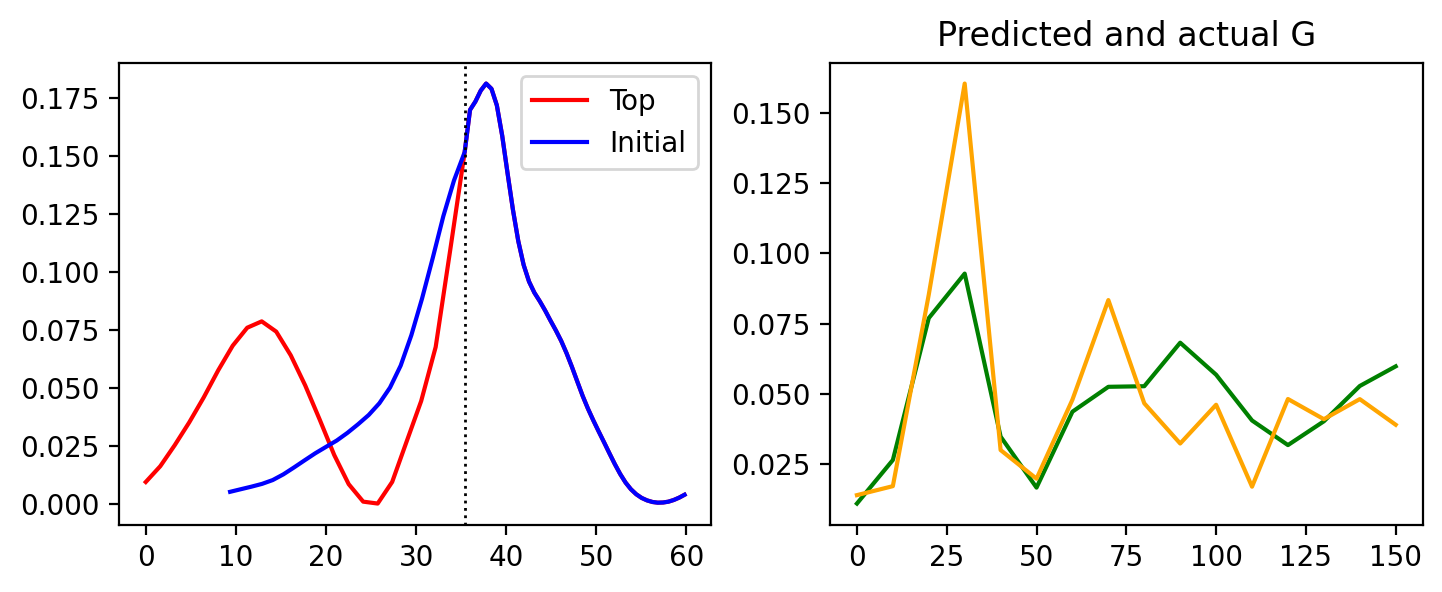

In [125]:

F = Fs[9]

plt.figure(figsize=(13, 3))

plt.subplot(1, 3, 1)

i_indices = config.get_Hpositions_for_branch('i')
t_indices = config.get_Hpositions_for_branch('t')

i_tps = config.get_timepoints_for_branch('i')
t_tps = config.get_timepoints_for_branch('t')

postg1_tps = config.get_timepoints_for_phase('postG1')

plt.plot(t_tps, F[t_indices], c='red', label="Top")
plt.plot(i_tps, F[i_indices], c='blue', label="Initial")
plt.axvline(postg1_tps[0], lw=1, ls='dotted', c='black')
plt.legend()

plt.subplot(1, 3, 2)

predicted_G = chr4_N_test@config.H@(F*sample_f_replication)
plt.plot(config.timepoints, predicted_G, c='green', label="Predicted G")
plt.plot(config.timepoints, selected_examples_G[:, 0], c='orange', label="G")
plt.title("Predicted and actual G")


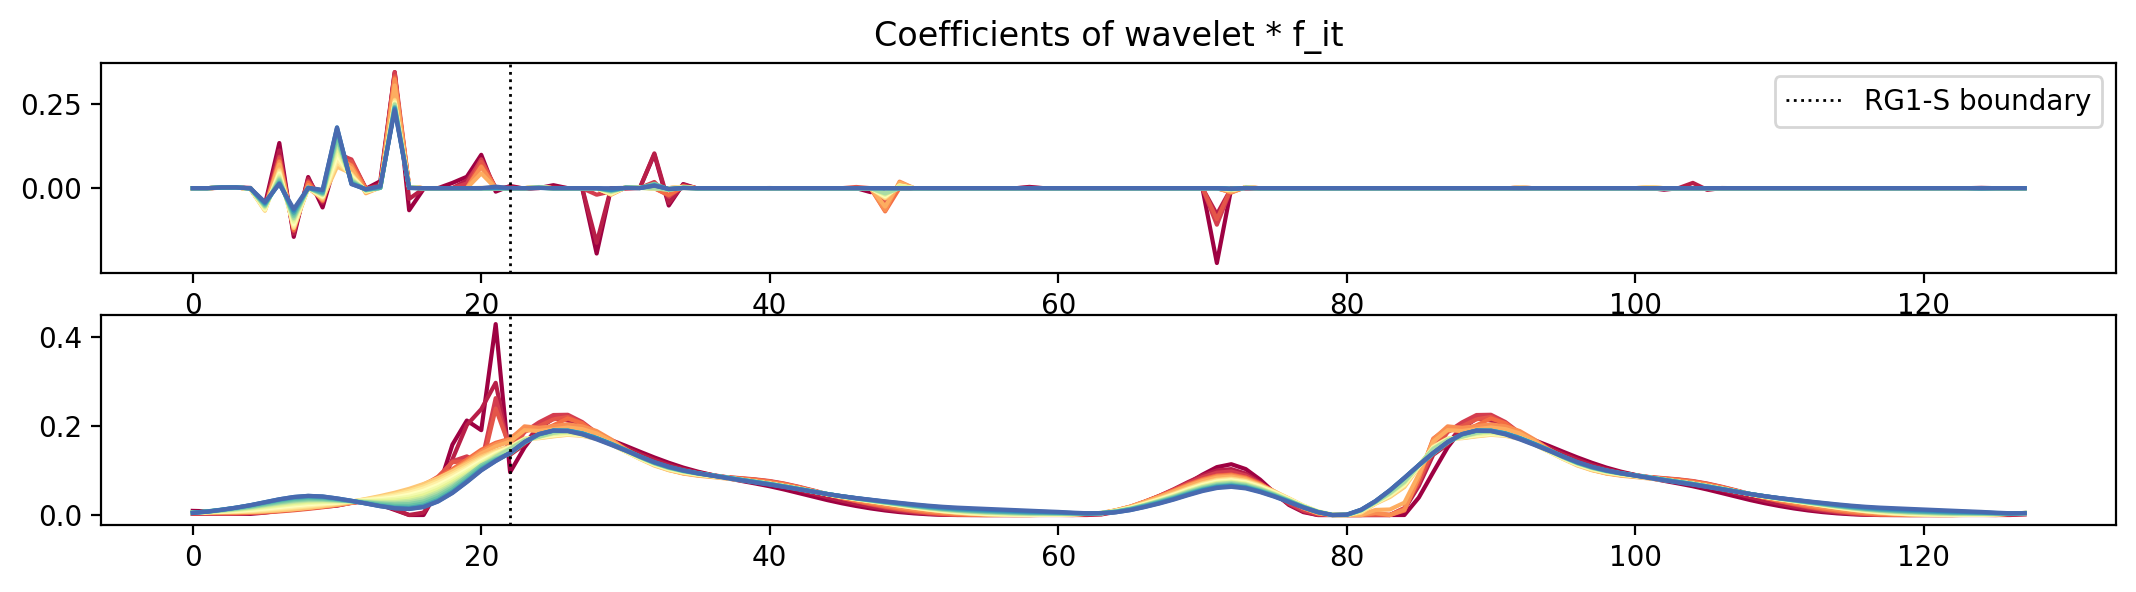

In [126]:
from src.helpers import get_wavelet_kernel

plt.figure(figsize=(13, 3))
plt.subplot(2, 1, 1)
f_it = np.concatenate([i_indices, t_indices])
W1 = get_wavelet_kernel(len(f_it))

cmap = plt.get_cmap('Spectral')
for i in range(Fs.shape[0]):
    F = Fs[i]
    plt.plot(W1@(F[f_it]), c=cmap(i/len(Fs)))

plt.axvline(len(config.get_Hpositions_for_phase('CG1')), label='RG1-S boundary',
           c='black', ls='dotted', lw=1)
plt.title("Coefficients of wavelet * f_it")
plt.legend()

plt.subplot(2, 1, 2)
for i in range(Fs.shape[0]):
    plt.plot(Fs[i, f_it], c=cmap(i/len(Fs)))

plt.axvline(len(config.get_Hpositions_for_phase('CG1')), label='RG1-S boundary',
           c='black', ls='dotted', lw=1)


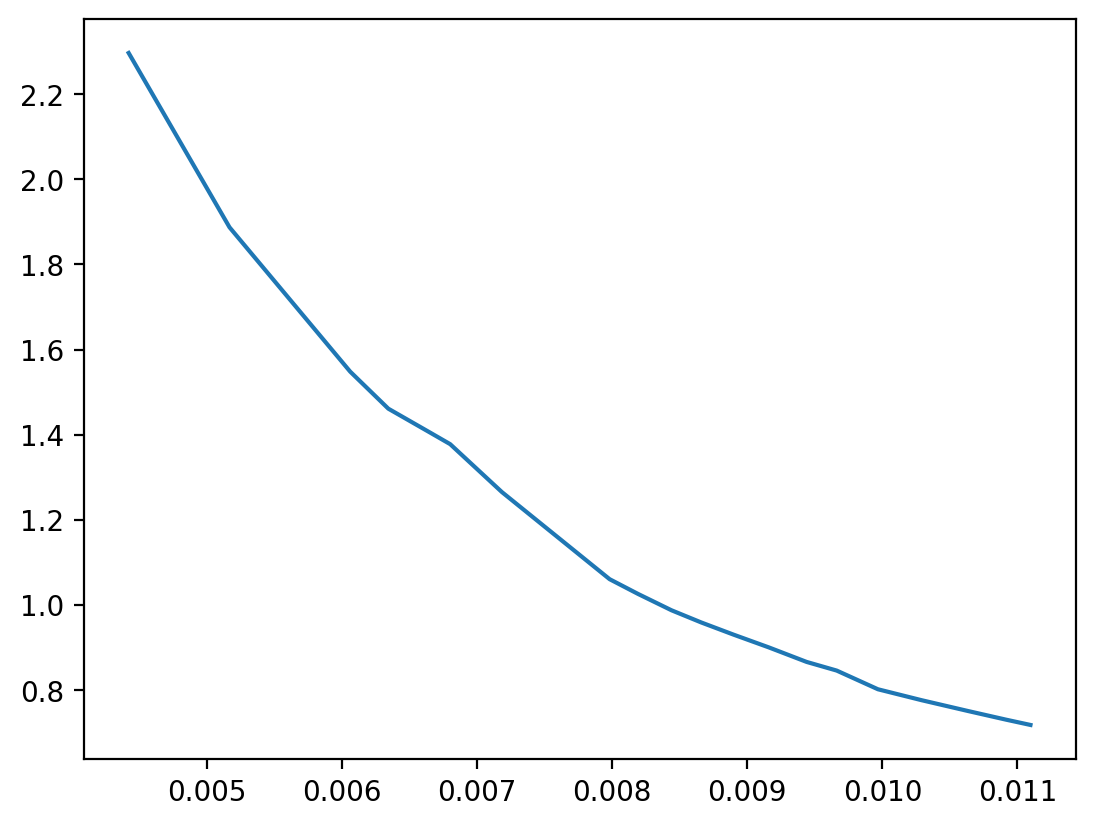

In [127]:
plt.plot(gamma_sweep_results_df.rn, gamma_sweep_results_df.sn)

In [108]:
gamma_sweep_results_df.index[len(gamma_sweep_results_df)//2]

0.005736842105263158

In [128]:
chromatin_solver = ChromatinDeconvolveSolver(config, config.H, 
    G, chr4_N_test, b, sample_f_replication, padding_type=padding_type)

In [129]:
F = chromatin_solver.deconvolve_G_iteratively(gamma=0.006)

0/780 - 00:00:00.049
500/780 - 00:00:23.600


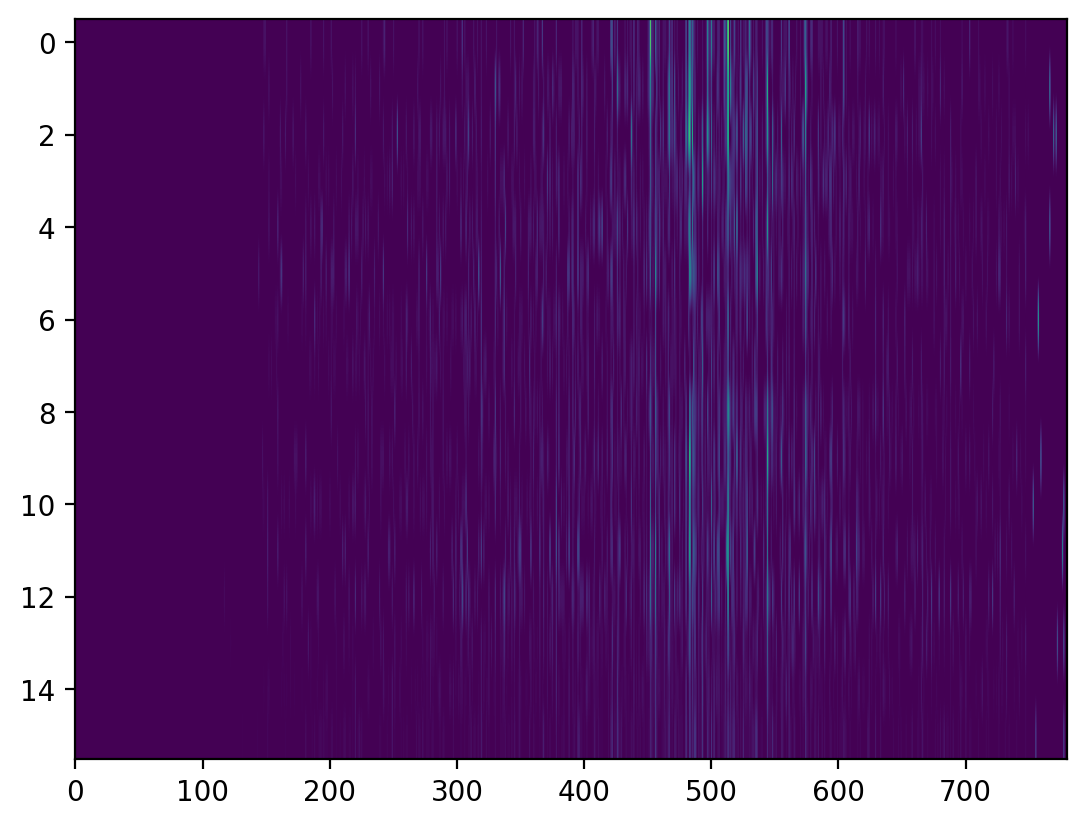

In [130]:
plt.imshow(G, aspect='auto')

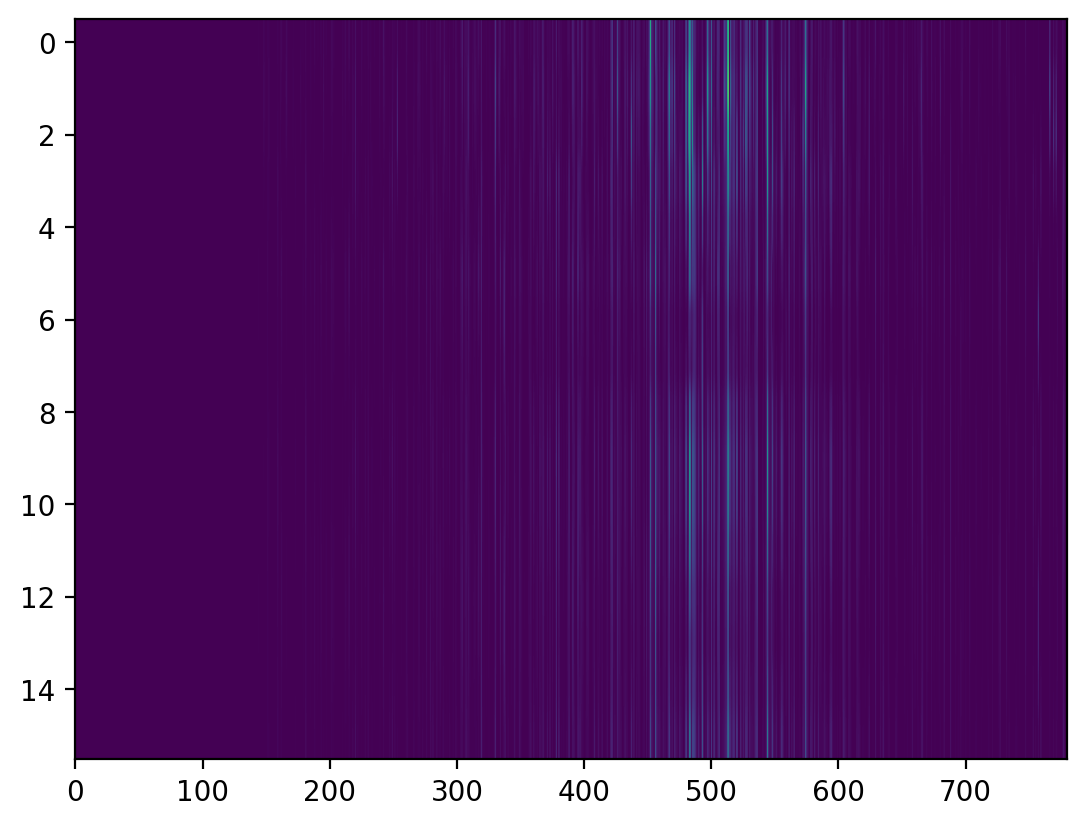

In [131]:
plt.imshow(config.H@F, aspect='auto')

0

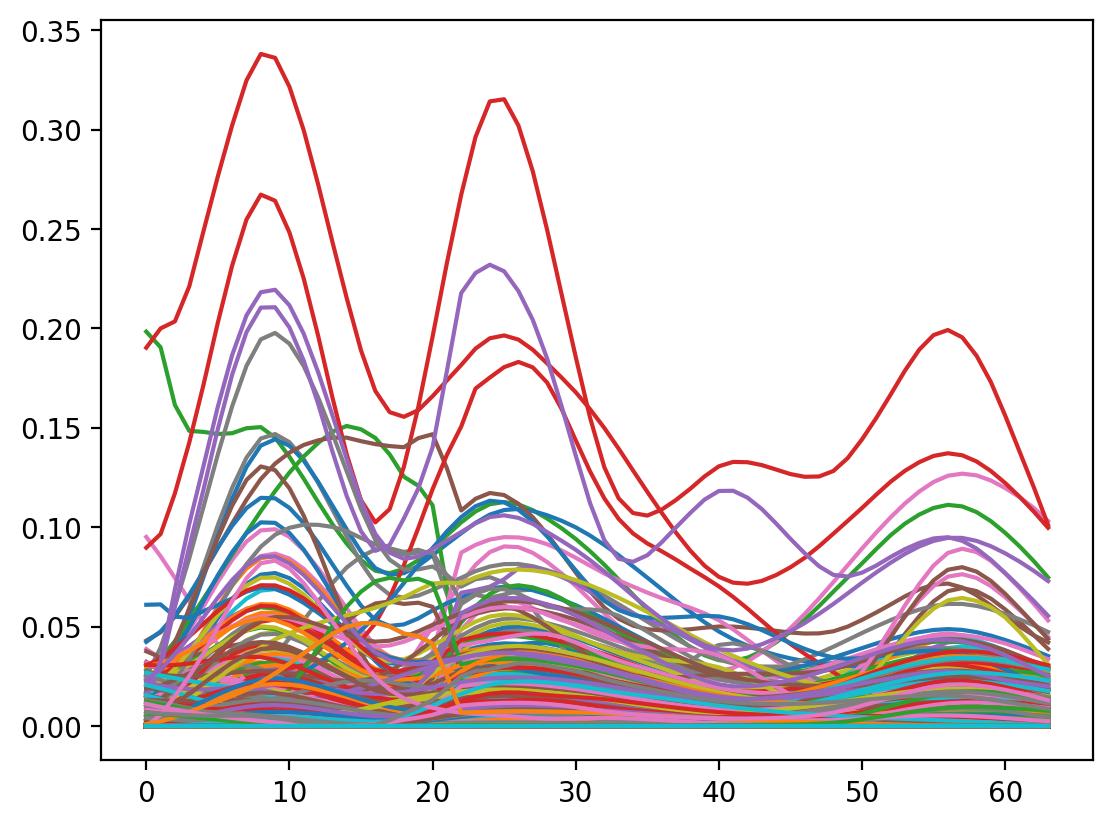

In [137]:
plt.plot(F[i_indices])

0

0

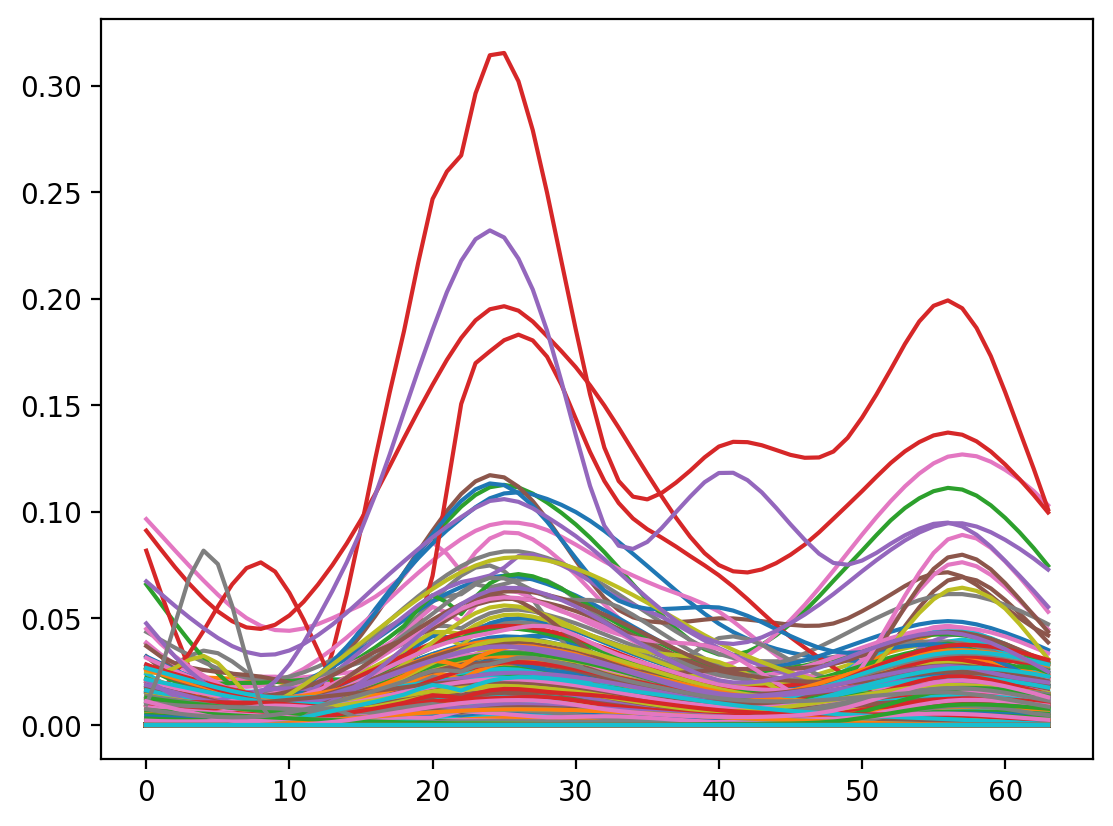

In [139]:
plt.plot(F[t_indices])
0